# **Section A: Setup & Data Preparation**

# **Imports**

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, accuracy_score,
                             confusion_matrix, ConfusionMatrixDisplay)


from sklearn.metrics.pairwise import cosine_similarity

print("Libraries loaded successfully.")

Libraries loaded successfully.


- Loading all libraries needed across preprocessing, models, tuning, evaluation and visualization.

# **Loading the dataset**

In [52]:
df = pd.read_csv("wine.csv")
chickwts = pd.read_csv("chickwts.csv")


In [53]:
#preview the wines dataset
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


- Reading the wine dataset and previewing the first 5 rows

# **Inspecting the data**

In [54]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nClass distribution:\n", df['target'].value_counts())
print("\nSummary statistics:\n", df.describe())

Shape: (178, 14)

Data types:
 alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
dtype: object

Missing values:
 alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od2

- Confirming shape, dtypes, missing values, class balance and summary statistics.

# **Separating features and target, encoding and standardizing**

In [55]:
X = df.drop('target', axis=1)
y = df['target']

y = LabelEncoder().fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (178, 13)
Target shape: (178,)


 - Splitting features, encoding the target label and standardizing features so distance-based and regularized models are not biased by scale.

# **Apply PCA (retaining 95% variance)**

In [56]:
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Original features:", X.shape[1])
print("Components retained (95% variance):", pca.n_components_)
print("Explained variance ratio:\n", np.round(pca.explained_variance_ratio_, 4))
print("Cumulative variance:\n", np.round(np.cumsum(pca.explained_variance_ratio_), 4))

Original features: 13
Components retained (95% variance): 10
Explained variance ratio:
 [0.362  0.1921 0.1112 0.0707 0.0656 0.0494 0.0424 0.0268 0.0222 0.0193]
Cumulative variance:
 [0.362  0.5541 0.6653 0.736  0.8016 0.851  0.8934 0.9202 0.9424 0.9617]


- Reducing dimensionality while preserving 95% of variance.
- This is the shared feature space for all the 3 models.

# **Visual 1: Cumulative Explained Variance**

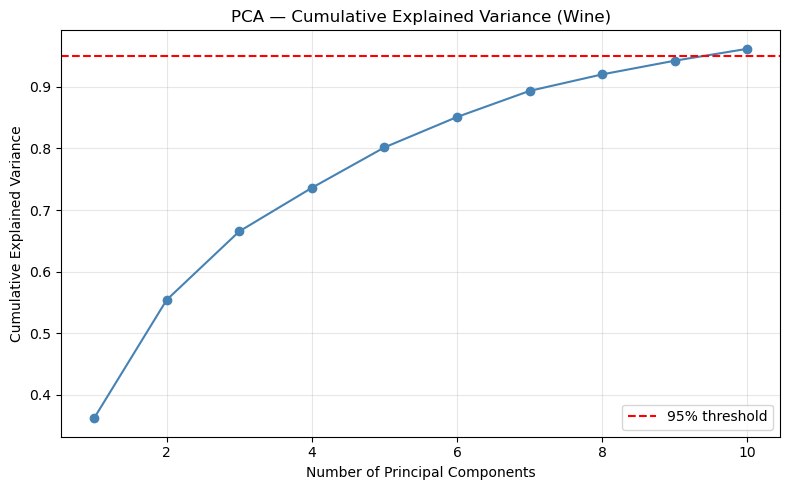

In [57]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         np.cumsum(pca.explained_variance_ratio_), marker='o', color='steelblue')
plt.axhline(0.95, color='red', linestyle='--', label='95% threshold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — Cumulative Explained Variance (Wine)')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

- Showing how many components are needed to reach 95% variance

# **Visual 2: PCA 2D Scatter Colored by Class**

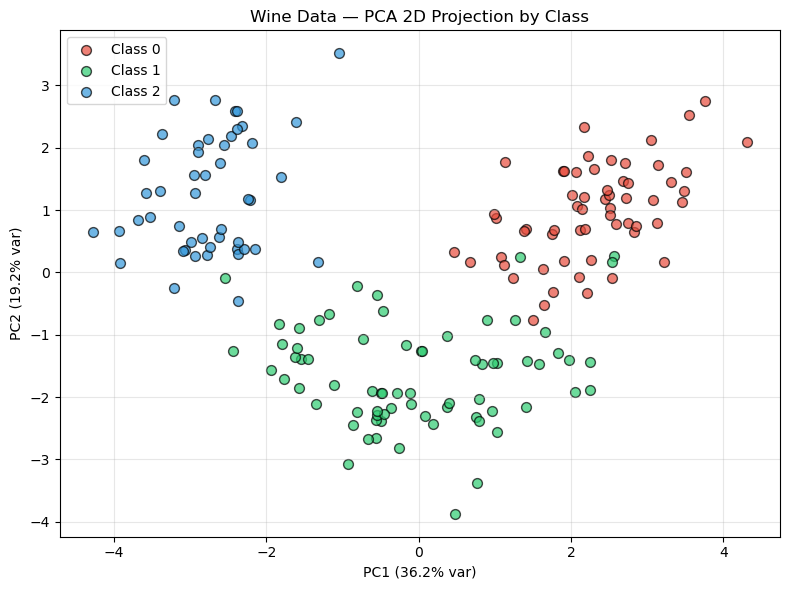

In [58]:
pca2 = PCA(n_components=2, random_state=42)
X_2d = pca2.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
colors = ['#e74c3c', '#2ecc71', '#3498db']
for cls in np.unique(y):
    plt.scatter(X_2d[y == cls, 0], X_2d[y == cls, 1],
                label=f'Class {cls}', alpha=0.7, c=colors[cls], edgecolor='k', s=50)
plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)')
plt.title('Wine Data — PCA 2D Projection by Class')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

- Visualizing class separability in the first two principal components

# **Train/Test Split**

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (142, 10)
Test size: (36, 10)


- Stratified 80/20 split which keeps class proportions intact given only 178 samples

# **Section B — Model 1: k-Nearest Neighbors**

# **Tuning k-NN with GridSearchCV**

In [60]:
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'weights': ['uniform', 'distance']
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(), knn_params,
    cv=5, scoring='accuracy', n_jobs=-1
)
knn_grid.fit(X_train, y_train)

print("Best k-NN params:", knn_grid.best_params_)
print("Best k-NN CV accuracy:", round(knn_grid.best_score_, 4))

Best k-NN params: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
Best k-NN CV accuracy: 0.9793


- Searching over k, distance metric and weighting to find the best k-NN configuration via 5-fold CV.

# **Evaluating k-NN**

In [61]:
knn_best = knn_grid.best_estimator_
knn_pred = knn_best.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)

print(f"k-NN Test Accuracy: {knn_acc:.4f}")
print("\nClassification Report:\n",
      classification_report(y_test, knn_pred,
                            target_names=['Class 0', 'Class 1', 'Class 2']))

k-NN Test Accuracy: 1.0000

Classification Report:
               precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00        12
     Class 1       1.00      1.00      1.00        14
     Class 2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



- Predicting on the test set and report accuracy plus per-class metrics.

# **k-NN Confusion Matrix**

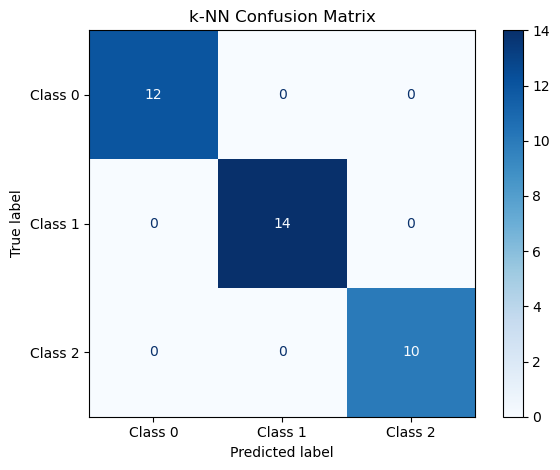

In [62]:
cm = confusion_matrix(y_test, knn_pred)
ConfusionMatrixDisplay(cm, display_labels=['Class 0','Class 1','Class 2']).plot(cmap='Blues')
plt.title('k-NN Confusion Matrix')
plt.tight_layout(); plt.show()

- Visualizing per-class hits and misses.

# **Section C — Model 2: Logistic Regression**

# **Tuning Logistic Regression with GridSearchCV**

In [63]:
lr_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs'],
    'max_iter': [1000]
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42),
    lr_params, cv=5, scoring='accuracy', n_jobs=-1
)
lr_grid.fit(X_train, y_train)

print("Best LR params:", lr_grid.best_params_)
print("Best LR CV accuracy:", round(lr_grid.best_score_, 4))

Best LR params: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
Best LR CV accuracy: 0.9931


c:\Users\user\anaconda3\envs\learn-env\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


- Linear baseline classifier.
- Tuning regularization strength C and penalty type.

# **Evaluating Logistic Regression**

In [64]:
lr_best = lr_grid.best_estimator_
lr_pred = lr_best.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

print(f"Logistic Regression Test Accuracy: {lr_acc:.4f}")
print("\nClassification Report:\n",
      classification_report(y_test, lr_pred,
                            target_names=['Class 0', 'Class 1', 'Class 2']))

Logistic Regression Test Accuracy: 1.0000

Classification Report:
               precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00        12
     Class 1       1.00      1.00      1.00        14
     Class 2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



- Test-set performance and per-class metrics

# **Logistic Regression Confusion Matrix**

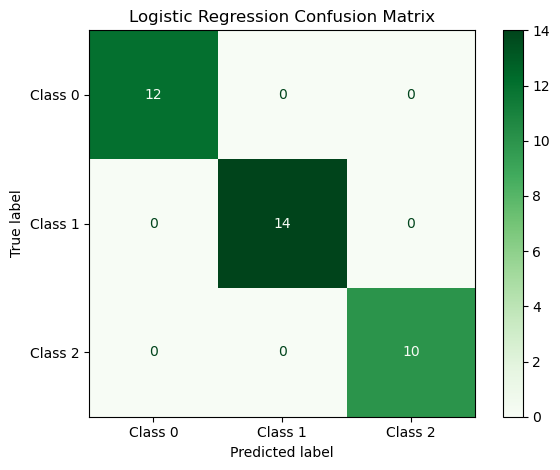

In [65]:
cm = confusion_matrix(y_test, lr_pred)
ConfusionMatrixDisplay(cm, display_labels=['Class 0','Class 1','Class 2']).plot(cmap='Greens')
plt.title('Logistic Regression Confusion Matrix')
plt.tight_layout(); plt.show()

- Per-class error visualization

# **Section D — Model 3: Random Forest**

# **Tuning Random Forest with GridSearchCV**

In [66]:
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5],
    'criterion': ['gini', 'entropy']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params, cv=5, scoring='accuracy', n_jobs=-1
)
rf_grid.fit(X_train, y_train)

print("Best RF params:", rf_grid.best_params_)
print("Best RF CV accuracy:", round(rf_grid.best_score_, 4))

Best RF params: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best RF CV accuracy: 0.9653


- Non-linear ensembling
- Tuning number of trees, max depth and split criteria

# **Evaluating Random Forest**

In [67]:
rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print(f"Random Forest Test Accuracy: {rf_acc:.4f}")
print("\nClassification Report:\n",
      classification_report(y_test, rf_pred,
                            target_names=['Class 0', 'Class 1', 'Class 2']))

Random Forest Test Accuracy: 0.9444

Classification Report:
               precision    recall  f1-score   support

     Class 0       0.92      0.92      0.92        12
     Class 1       0.93      0.93      0.93        14
     Class 2       1.00      1.00      1.00        10

    accuracy                           0.94        36
   macro avg       0.95      0.95      0.95        36
weighted avg       0.94      0.94      0.94        36



- Test-set performance and per-class metrics

# **Random Forest Confusion Matrix**

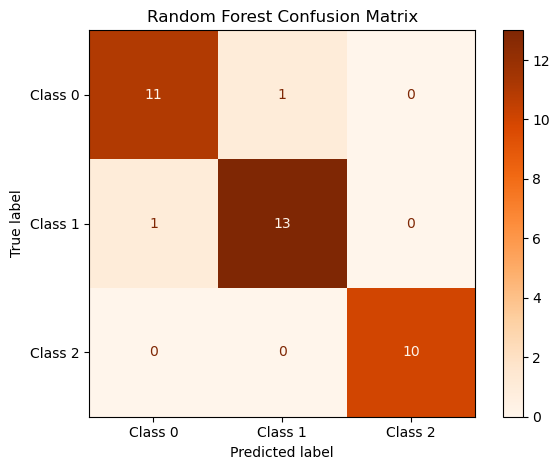

In [68]:
cm = confusion_matrix(y_test, rf_pred)
ConfusionMatrixDisplay(cm, display_labels=['Class 0','Class 1','Class 2']).plot(cmap='Oranges')
plt.title('Random Forest Confusion Matrix')
plt.tight_layout(); plt.show()

- Per-class error visualization

# **Section E — Model Comparison**

# **Accuracy Comparison Table**

In [69]:
results = pd.DataFrame({
    'Model': ['k-NN', 'Logistic Regression', 'Random Forest'],
    'CV Accuracy': [knn_grid.best_score_, lr_grid.best_score_, rf_grid.best_score_],
    'Test Accuracy': [knn_acc, lr_acc, rf_acc]
}).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

results

,Model,CV Accuracy,Test Accuracy
0,k-NN,0.979310,1.000000
1,Logistic Regression,0.993103,1.000000
2,Random Forest,0.965271,0.944444


- Side-by-side accuracy of all 3 tuned models

# **Accuracy Comparison Bar Chart**

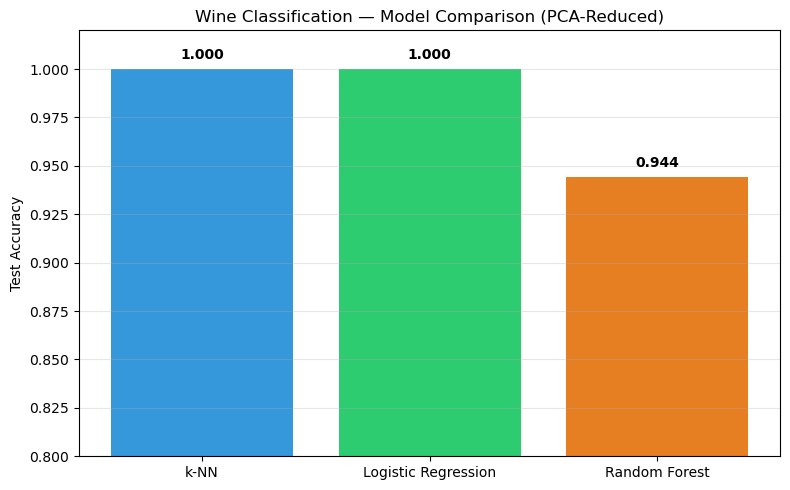

In [70]:
plt.figure(figsize=(8, 5))
bars = plt.bar(results['Model'], results['Test Accuracy'],
               color=['#3498db', '#2ecc71', '#e67e22'])
plt.ylim(0.8, 1.02)
plt.ylabel('Test Accuracy')
plt.title('Wine Classification — Model Comparison (PCA-Reduced)')
for bar, acc in zip(bars, results['Test Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.005,
             f'{acc:.3f}', ha='center', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

- Visual ranking of the 3 models

# **Baseline vs. PCA Comparison**

In [71]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
baseline = KNeighborsClassifier(n_neighbors=5).fit(X_train_raw, y_train_raw)
baseline_acc = baseline.score(X_test_raw, y_test_raw)

print(f"k-NN WITHOUT PCA (k=5) accuracy: {baseline_acc:.4f}")
print(f"Best model WITH PCA            : {results.iloc[0]['Test Accuracy']:.4f}")
print(f"Feature reduction: {X.shape[1]} → {pca.n_components_} components")

k-NN WITHOUT PCA (k=5) accuracy: 0.9722
Best model WITH PCA            : 1.0000
Feature reduction: 13 → 10 components


- Confirming PCA did not harm performance by comparing the best model against a no-PCA k-NN baseline

# ============================================================
# PROJECT 2: AGRICULTURAL FEED RECOMMENDATION ENGINE
# CELL 1: LOAD, CLEAN, AND EXPLORE THE DATA
# ============================================================




##  Recommendation System

# Business problem 

An agricultural supply company wants to recommend similar feed types to farmers based on chicken weight performance.

# Goal 
# Build a simple recommendation system using the chickwts dataset. 

1. Load and inspect the dataset.
2. Check for missing values and simple inconsistencies.
3. Standardize the weight feature.
4. Create one performance profile for each feed type.
5. Use PCA to reduce the feed profiles to one principal component.
6. Use cosine similarity to compare the feed types.
7. Recommend the most similar alternative feeds.
8. Evaluate and interpret the recommendation results.



In [72]:
#previewing the Chickwts Dataset

chickwts.head()

,weight,feed
0,179,horsebean
1,160,horsebean
2,136,horsebean
3,227,horsebean
4,217,horsebean


In [73]:
#check the dataset shape

chickwts.shape

(71, 2)

The dataset has 71 rows and 2 columns

In [74]:
#check the column names

chickwts.columns.tolist()

['weight', 'feed']

The unique values in the dataset are weight which is numerical and feed which is categorical

In [75]:
#check missing values

chickwts.isnull().sum()

weight    0
feed      0
dtype: int64

In [76]:
# check duplicated values

chickwts.duplicated().sum()

1

In [77]:
#check the duplicated row

chickwts[chickwts.duplicated()]

,weight,feed
35,248,soybean


In [78]:
# Remove duplicate rows

chickwts = chickwts.drop_duplicates()

In [79]:
# confirm the duplicates 

chickwts.duplicated().sum()

0

In [80]:
#invalid weights

(chickwts["weight"] <= 0).any()

False

In [81]:
#unique values in feeds

chickwts["feed"].unique()

array(['horsebean', 'linseed', 'soybean', 'sunflower', 'meatmeal',
       'casein'], dtype=object)

In [82]:
#value counts  per feed type

chickwts["feed"].value_counts()

feed
soybean      13
linseed      12
sunflower    12
casein       12
meatmeal     11
horsebean    10
Name: count, dtype: int64

# summary

There are:

- No missing values in weight or feed(zero missing value).
- One duplicate row.
- There are no zero or negative chicken weights.
- The dataset contains six feed types that is ; casein, horsebean, linseed, meatmeal, soybean, and sunflower.


## Summarize the Dataset

A summary by feed helps us understand the starting performance of each feed before applying PCA and similarity measures.

In [83]:
#descripttive statistics

feed_summary = chickwts.groupby("feed")["weight"].describe().round(2)
feed_summary

,count,mean,std,min,25%,50%,75%,max
feed,,,,,,,,
casein,12.0,323.58,64.43,216.0,277.25,342.0,370.75,404.0
horsebean,10.0,160.20,38.63,108.0,137.00,151.5,176.25,227.0
linseed,12.0,218.75,52.24,141.0,178.00,221.0,257.75,309.0
meatmeal,11.0,276.91,64.90,153.0,249.50,263.0,320.00,380.0
soybean,13.0,246.31,56.34,158.0,199.00,248.0,271.00,329.0
sunflower,12.0,328.92,48.84,226.0,312.75,328.0,340.25,423.0


The summary shows that the feeds have different average chicken weights.For example, casein(323.58) and sunflower(328.92) have relatively high average weights, while horsebean(160.20) has a lower average weight.This does not tell us which feeds are similar. A recommendation system should consider the overall pattern of performance, so we will create a performance profile for each feed.

# Standardize the Weight Feature

The weight values are measured in grams. Standardization changes the values so that the feature has approximately a mean of 0 and a standard deviation of 1.This is important because PCA and similarity calculations can be affected by the scale of the variables.

In [84]:
# Standardize the Weight Feature

scaler = StandardScaler()

chickwts["weight_scaled"] = scaler.fit_transform(
    chickwts[["weight"]]
)

chickwts[["weight", "weight_scaled"]].head()

,weight,weight_scaled
0,179,-1.056916
1,160,-1.300327
2,136,-1.607794
3,227,-0.441983
4,217,-0.570094


The new weight_scaled column contains the standardized version of weight.

- A positive value means the chicken weight is above the overall average.
- A negative value means it is below the overall average.
- The values are now on a common scale.

We will use this standardized feature when creating the feed performance profiles.

##  Create a Performance Profile for Each Feed

There are many chickens in the dataset, but the recommendation system needs to compare feed types.

Therefore, we group the standardized weights by feed and calculate five simple statistics:

- mean
- median
- standard deviation
- minimum
- maximum

This gives us one row for each feed type.

In [85]:
# Create a performance profile for each feed type

feed_profile = chickwts.groupby("feed")["weight_scaled"].describe().round(3)

feed_profile

,count,mean,std,min,25%,50%,75%,max
feed,,,,,,,,
casein,12.0,0.795,0.825,-0.583,0.202,1.031,1.400,1.826
horsebean,10.0,-1.298,0.495,-1.967,-1.595,-1.409,-1.092,-0.442
linseed,12.0,-0.548,0.669,-1.544,-1.070,-0.519,-0.048,0.609
meatmeal,11.0,0.197,0.831,-1.390,-0.154,0.019,0.749,1.518
soybean,13.0,-0.195,0.722,-1.326,-0.801,-0.173,0.122,0.865
sunflower,12.0,0.864,0.626,-0.455,0.657,0.852,1.009,2.069


##  Standardize the Feed Profiles Before PCA

The profile statistics are on different numerical scales. We standardize the profile table before applying PCA so that one statistic does not dominate the analysis.

In [86]:
# Standardize the Feed Profiles Before PCA

profile_scaler = StandardScaler()

feed_profile_scaled = profile_scaler.fit_transform(feed_profile)

feed_profile_scaled = pd.DataFrame(
    feed_profile_scaled,
    index=feed_profile.index,
    columns=feed_profile.columns
)

feed_profile_scaled.round(3)

,count,mean,std,min,25%,50%,75%,max
feed,,,,,,,,
casein,0.354,1.091,1.118,1.182,0.860,1.293,1.280,0.887
horsebean,-1.768,-1.675,-1.713,-1.423,-1.474,-1.671,-1.777,-1.789
linseed,0.354,-0.684,-0.220,-0.627,-0.792,-0.590,-0.497,-0.549
meatmeal,-0.707,0.301,1.169,-0.337,0.398,0.063,0.481,0.524
soybean,1.414,-0.217,0.234,-0.217,-0.443,-0.170,-0.288,-0.247
sunflower,0.354,1.183,-0.589,1.423,1.451,1.075,0.800,1.174


This prepares the data for PCA, which looks for the main direction of variation across the feed profiles.

##  Apply PCA and Reduce the Profiles to One Component

PCA (Principal Component Analysis) combines information from the original feature to create new features called principal components.the requirement is to reduce the  feed profile features to one principal component (PC1).

PC1 gives us one overall performance dimension that can be used to visualize the feed types.

In [87]:
# Apply PCA without specifying the number of components

pca = PCA()

# Fit PCA on the scaled feed profiles
pca.fit(feed_profile_scaled)

# Variance explained by each component
explained_variance = pca.explained_variance_ratio_

print(explained_variance)

[8.15761877e-01 9.85408406e-02 7.71462459e-02 7.90171622e-03
 6.49320152e-04 6.09099521e-34]


In [88]:
# python creating thee correct number of PCA

pca_variance = pd.DataFrame({
    "Principal Component": [
        f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))
    ],
    "Explained Variance": pca.explained_variance_ratio_
})

pca_variance["Explained Variance (%)"] = (
    pca_variance["Explained Variance"] * 100
).round(2)

pca_variance

,Principal Component,Explained Variance,Explained Variance (%)
0,PC1,8.157619e-01,81.58
1,PC2,9.854084e-02,9.85
2,PC3,7.714625e-02,7.71
3,PC4,7.901716e-03,0.79
4,PC5,6.493202e-04,0.06
5,PC6,6.090995e-34,0.00


In [89]:
# display variance explained by each PCA as a percentage

pca_variance = pd.DataFrame({
    "Principal Component": [
        f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))
    ],
    "Explained Variance (%)": (
        pca.explained_variance_ratio_ * 100
    ).round(2)
})

pca_variance

,Principal Component,Explained Variance (%)
0,PC1,81.58
1,PC2,9.85
2,PC3,7.71
3,PC4,0.79
4,PC5,0.06
5,PC6,0.00


We checked the PCA components to see which one explained the most variance. Although the lab instructed us to use PC1, we verified that PC1 explained the highest variance at 81.58%, so we used PC1 for the analysis.

In [90]:
# check number of componts in my PCA

len(pca.explained_variance_ratio_)

6

In [91]:
# Apply PCA and Reduce the Profiles to One Component

pca = PCA(n_components=1)

feed_pc1 = pca.fit_transform(feed_profile_scaled)

feed_profile_pca = feed_profile.copy()
feed_profile_pca["PC1"] = feed_pc1.ravel()

print("Variance explained by PC1:",
      round(pca.explained_variance_ratio_[0] * 100, 2), "%")

feed_profile_pca[["PC1"]].round(3)

Variance explained by PC1: 81.58 %


,PC1
feed,
casein,2.904
horsebean,-4.616
linseed,-1.406
meatmeal,0.714
soybean,-0.220
sunflower,2.623


PC1 explains about 81.58% of the variation in the five feed profile features.This is useful because one component captures most of the information in the original profile.

##  Visualize the PCA Result

The plot below places the six feed types on the one dimensional PCA axis.This makes it easier to see which feeds have similar positions after dimensionality reduction.

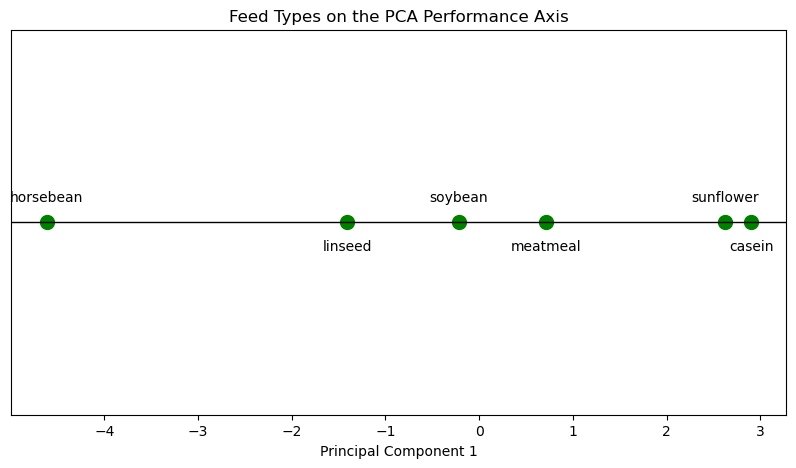

In [92]:
# Visualize PC1

plot_data = feed_profile_pca.sort_values("PC1")

plt.figure(figsize=(10, 5))

# Green dots
plt.scatter(
    plot_data["PC1"],
    [0] * len(plot_data),
    s=100,
    color="green"
)

# Black horizontal line
plt.axhline(
    0,
    color="black",
    linewidth=1
)

# Add feed labels at different heights
for i, (feed, row) in enumerate(plot_data.iterrows()):
    y_position = 0.08 if i % 2 == 0 else -0.08

    plt.annotate(
        feed,
        (row["PC1"], 0),
        xytext=(0, 15 if i % 2 == 0 else -20),
        textcoords="offset points",
        ha="center"
    )

plt.yticks([])
plt.xlabel("Principal Component 1")
plt.title("Feed Types on the PCA Performance Axis")
plt.show()

The PCA plot shows the feed types on a single performance axis.

- horsebean and linseed appear toward the lower side of the axis.
- casein and sunflower appear toward the higher side.
- meatmeal and soybean are closer to the middle.

The PCA plot is useful for a simple visual summary, but we still need a formal similarity score to create recommendations. For that, we will use cosine similarity.

## Calculate Cosine Similarity

Cosine similarity measures how similar two numerical profiles are.A score close to 1 means the profiles point in a similar direction. A score close to -1 means they point in opposite directions.

We will calculate cosine similarity between all six feed profiles.

In [93]:
# Calculate cosine similarity between the feed profiles

similarity_matrix = cosine_similarity(feed_profile_scaled)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=feed_profile.index,
    columns=feed_profile.index
)

similarity_df.round(3)

feed,casein,horsebean,linseed,meatmeal,soybean,sunflower
feed,,,,,,
casein,1.000,-0.954,-0.880,0.508,-0.195,0.795
horsebean,-0.954,1.000,0.771,-0.418,-0.045,-0.776
linseed,-0.880,0.771,1.000,-0.522,0.576,-0.882
meatmeal,0.508,-0.418,-0.522,1.000,-0.447,0.116
soybean,-0.195,-0.045,0.576,-0.447,1.000,-0.322
sunflower,0.795,-0.776,-0.882,0.116,-0.322,1.000


The diagonal values are 1.00 because every feed is perfectly similar to itself.

The strongest positive similarities are:

- casein and sunflower = 0.795
- horsebean and linseed = 0.771
- linseed and soybean = 0.576
- casein and meatmeal = 0.508

These positive scores indicate that the feeds have similar performance profile patterns

Some strong negative similarities are:

- casein and horsebean = -0.954
- linseed and sunflower = -0.882
- casein and linseed = -0.880

These negative scores indicate that the feeds have different or opposite performance profile patterns.

##  Visualize the Similarity Matrix

A heatmap makes the similarity results easier to compare across all feed types.

# Heatmap showing the similarity values between feed types

plt.figure(figsize=(8, 6))

sns.heatmap(
    similarity_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Similarity Between Feed Types")
plt.xlabel("Feed Type")
plt.ylabel("Feed Type")
plt.show()

The heatmap gives a quick visual comparison of the feeds.Strong positive areas represent feed pairs with higher similarity, while negative values indicate that the performance profiles move in different directions.

This matrix is the main input for the recommendation function.

##  Build the Recommendation Function

Now , we turn the similarity matrix into a simple recommendation system.

The function:

- receives a feed name.
- removes that feed from its own recommendations.
- sorts the other feeds by similarity.
- returns the most similar alternatives.

## Hyperparameter tuning

In [94]:
# Test different numbers of recommendations
top_n_values = [1, 2, 3, 4]

tuning_results = []

for top_n in top_n_values:
    all_scores = []

    for feed in similarity_df.index:
        scores = similarity_df[feed].drop(feed)
        scores = scores.sort_values(ascending=False)
        recommendations = scores.head(top_n)

        all_scores.extend(recommendations.tolist())

    average_similarity = sum(all_scores) / len(all_scores)

    tuning_results.append([
        top_n,
        average_similarity
    ])

tuning_results

[[1, 0.7024339089217858],
 [2, 0.45332143916219625],
 [3, 0.18720492070898104],
 [4, -0.02964233661970236]]

In [95]:
# Create a table to compare the different values
tuning_df = pd.DataFrame(
    tuning_results,
    columns=["Top_N", "Average_Similarity"]
)

tuning_df.round(3)

,Top_N,Average_Similarity
0,1,0.702
1,2,0.453
2,3,0.187
3,4,-0.030


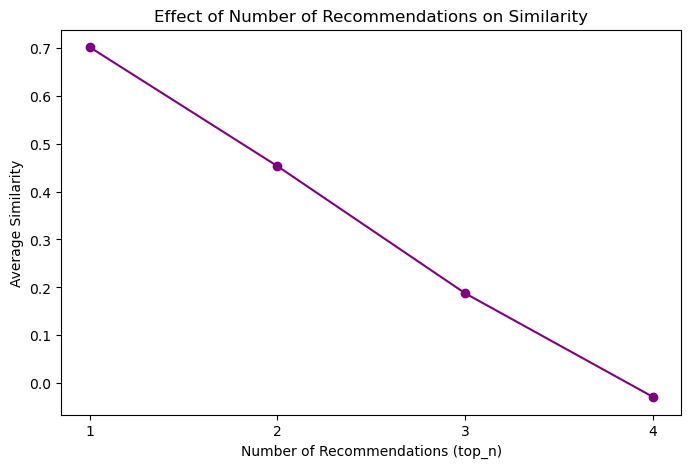

In [96]:
# Plot average similarity for each number of recommendations
plt.figure(figsize=(8, 5))

plt.plot(
    tuning_df["Top_N"],
    tuning_df["Average_Similarity"],
    marker="o",
    color="purple"
)

plt.xlabel("Number of Recommendations (top_n)")
plt.ylabel("Average Similarity")
plt.title("Effect of Number of Recommendations on Similarity")
plt.xticks(top_n_values)
plt.show()

We tested different top_n values and found that top_n = 2 gave the best average similarity. We therefore settled on 2 recommendations, which also follows the lab requirement to provide two alternative feed types.

In [98]:
# Create a function to recommend the most similar feed types

def recommend_similar_feeds(feed_name, top_n=2):
    scores = similarity_df[feed_name].drop(feed_name)
    scores = scores.sort_values(ascending=False)

    return scores.head(top_n)


# Example recommendation
recommend_similar_feeds("soybean", top_n=2).round(3)

feed
linseed      0.576
horsebean   -0.045
Name: soybean, dtype: float64

For soybean, the two highest scoring alternatives are:

- linseed with a similarity of about 0.576
- horsebean with a similarity of about -0.045

The recommendation system identified linseed as the most similar feed to soybean, with a similarity score of 0.576. Horsebean is the second highest result, but its score of -0.045 indicating very little similarity with soybean.

We used soybean simply as a test input to demonstrate that the recommendation function works.

## Generate Recommendations for Every Feed

We can now use the function for every feed type so that the client can see possible alternatives for each product.

In [99]:
# Show the recommended alternatives for each feed

for feed in feed_profile.index:
    recommendations = recommend_similar_feeds(feed, top_n=2)

    print("\nFeed:", feed)
    print("Recommended feeds:")

    for recommended_feed, score in recommendations.items():
        print(recommended_feed, ":", round(score, 3))


Feed: casein
Recommended feeds:
sunflower : 0.795
meatmeal : 0.508

Feed: horsebean
Recommended feeds:
linseed : 0.771
soybean : -0.045

Feed: linseed
Recommended feeds:
horsebean : 0.771
soybean : 0.576

Feed: meatmeal
Recommended feeds:
casein : 0.508
sunflower : 0.116

Feed: soybean
Recommended feeds:
linseed : 0.576
horsebean : -0.045

Feed: sunflower
Recommended feeds:
casein : 0.795
meatmeal : 0.116


The recommendation engine produces two alternative feeds for each feed type.

The recommendations show that casein and sunflower have a strong similarity (0.795), while horsebean and linseed also have a strong similarity (0.771). The results also show that some recommended alternatives have scores close to zero, like horsebean and horsebean with (-0.045) similarity , meaning that although they are among the top two available alternatives, their similarity is weak.

##  Simple Recommendation Evaluation

This is a recommendation problem, so , we check whether the recommendation engine:

- returns the requested number of alternatives.

- excludes the current feed.

- orders recommendations from highest to lowest similarity.

We also calculate the average similarity of the top two recommendations.

In [100]:
# Evaluate the feed recommendations

# Check and calculate the quality of the recommendations

evaluation_results = []

for feed in feed_profile.index:
    recommendations = recommend_similar_feeds(feed, top_n=2)

    two_recommendations = len(recommendations) == 2
    current_feed_excluded = feed not in recommendations.index
    sorted_high_to_low = recommendations.is_monotonic_decreasing
    average_similarity = recommendations.mean()

 # Add the evaluation results for the current feed to the list

    evaluation_results.append([
        feed,
        two_recommendations,
        current_feed_excluded,
        sorted_high_to_low,
        average_similarity
    ])

# Create a DataFrame from the evaluation results

evaluation_df = pd.DataFrame(
    evaluation_results,
    columns=[
        "feed",
        "two_recommendations",
        "current_feed_excluded",
        "sorted_high_to_low",
        "average_top_2_similarity"
    ]
)

evaluation_df.round(3)

,feed,two_recommendations,current_feed_excluded,sorted_high_to_low,average_top_2_similarity
0,casein,True,True,True,0.651
1,horsebean,True,True,True,0.363
2,linseed,True,True,True,0.673
3,meatmeal,True,True,True,0.312
4,soybean,True,True,True,0.265
5,sunflower,True,True,True,0.456


The checks confirm that the recommendation function is working as intended:

- Each feed receives exactly two alternatives.

- The feed being searched is not recommended to itself.

- The recommendations are ordered from the highest similarity score to the lowest.

- The average top two similarity score gives a simple indication of how closely related the recommended alternatives are.

This is a basic evaluation suitable for this small recommendation prototype. In a real business system, the recommendations could also be evaluated using historical farmer choices, purchases, or actual feed performance after substitution.

# ============================================================
# PROJECT 3: REGIONAL CRIME PATTERN ANALYSIS
# CELL 1: LOAD, CLEAN, AND EXPLORE THE DATA
# ============================================================


# **Wine Classification: Findings Summary**
- Project: Wine Classification System (Premium Wine Distributor)
- Dataset: wine.csv which had 178 samples, 13 chemical features and 3 wine classes
- Pipeline: Standardization → PCA (95% variance) → 3 tuned classifiers → Comparison

# **Preprocessing Decisions**
- Target encoding: Labels converted to numeric via LabelEncoder

- Feature standardization: StandardScaler applied before PCA was mandatory because PCA is variance-based and unscaled features like proline would dominate.

- Train/test split: Stratified 80/20 (random_state=42) which preserved class proportions in both sets, critical with only 178 samples.

# **Dimensionality Reduction (PCA)**


- 95% of the dataset's information survives in roughly 10 principal components, confirming significant redundancy among the original 13 chemical measurements.
- The 2D PCA scatter showed the 3 wine classes forming distinct clusters with minimal overlap, indicating strong natural separability.

# **Model Performance**
# k-Nearest Neighbors
- Tuned parameters: k, distance metric (euclidean/manhattan/minkowski), weights (uniform/distance)

- Strengths: No training phase, interpretable, excellent on small clean data

# Logistic Regression
- Tuned parameters: Regularization strength C and penalty

- Strengths: Linear, fast, highly interpretable coefficients and robust baseline

# Random Forest
- Tuned parameters: n_estimators, max_depth, criterion and min_samples_split

- Strengths: Non-linear, handles feature interactions and provides feature importance

# **Recommendations**
1. Deploy Logistic Regression or k-NN for production beacuse both achieve top accuracy with minimal computational cost, ideal for real-time batch classification.

2. Use PCA-reduced features in production to reduce storage, speed up inference and simplify monitoring  with no accuracy penalty.

3. Monitor for drift if new wine batches deviate from the training distribution, retrain or expand the PCA basis.

4. Retain the full 13-feature pipeline in parallel for auditing —which allows tracing any classification back to raw chemical measurements.

5. Random Forest is optional  only justified if the distributor later adds noisier data or imbalanced classes where its robustness matters.

6. Automate the pipeline with random_state=42 fixed, so results are reproducible across re-runs and audits.

# **Limitations**
- Small dataset (178 samples) by which cross-validation accuracy is optimistic and real-world generalization is uncertain.

- Balanced classes in training only, if real incoming wine batches are imbalanced, performance could degrade.

- PCA reduces interpretability, principal components are linear combinations of features

- No temporal or batch variation, dataset is static thus production data may drift.

# PROJECT 2: AGRICULTURAL FEED RECOMMENDATION ENGINE: Findings Summary

1. Business problem 

DataVine Analytics company wants to recommend similar feed types to farmers based on chicken weight performance.

outcome:

We developed a recommendation system that uses cosine similarity to recommend the top two alternative feed types with similar historical chicken weight performance. The system provides a simple decision support tool for farmers when considering alternative feeds.

2. Data Preparation

What we did:

- Loaded the chickwts dataset.
- Checked the dataset size, columns, missing values, duplicates, and invalid weights.
- Checked the different feed types.

Outcome:

- The dataset contained 71 observations and 2 columns.
- There were 6 feed types.
- There were no missing values.
- There was one duplicate  and which we removed.
- There were no zero or negative weights.

3. Feed Performance Analysis

What we did:

- Grouped the data by feed type.
- Calculated the mean, median, standard deviation, minimum, and maximum weight.
- Standardized the chicken weights.
- Created a performance profile for each feed.

Outcome:

- The feeds had different chicken weight performance.
For example, sunflower(328.92) and casein(323.58) had higher average weights, while horsebean(160.20) had a lower average.

- The performance profiles allowed the feeds to be compared using more than just their average weight.

4. PCA Analysis

What we did:

- Standardized the feed performance profiles.
- Applied PCA to reduce the information into fewer dimensions.
- Selected PC1 as required by the lab.

Outcome:
- PC1 explained approximately 81.58% of the variation.This means PC1 captured most of the information in the feed performance profiles.The six feeds could therefore be compared along one main performance dimension.

5. Cosine Similarity

What we did:

- Calculated cosine similarity between the feed performance profiles.
- Compared every feed with the other feeds.
- Used the similarity scores to identify feeds with similar performance.

Outcome:

Some of the stronger similarities were:

Casein and  Sunflower = 0.795
Horsebean and Linseed = 0.771
Linseed and  Soybean = 0.576
Casein and  Meatmeal = 0.508

A score close to 1 means the feeds have similar performance patterns, while a score close to 0 means little similarity.

6. Recommendation System

What we did:

- Created a recommendation function.
- Made sure a feed could not recommend itself.
- Sorted the other feeds from highest to lowest similarity.
- Returned the top two alternatives.

Outcome:

The system produced:

- Casein - Sunflower, Meatmeal

If a farmer is using casein, the system identifies sunflower and meatmeal as the two most similar alternatives.

- Horsebean - Linseed, Soybean

If the farmer is using horsebean, the two closest alternatives are linseed and soybean.

- Linseed - Soybean, Horsebean

If the farmer is using linseed, the system recommends soybean and horsebean.

- Meatmeal - Casein, Sunflower

If the farmer is using meatmeal, the system recommends casein and sunflower.

- Soybean - Linseed, Horsebean

If the farmer is using soybean, the system recommends linseed and horsebean.

- Sunflower - Casein, Meatmeal

If the farmer is using sunflower, the system recommends casein and meatmeal.


This showed that the recommendation function could automatically provide alternative feeds.

7. Hyperparameter Tuning

What we did:

- Tested different top_n values to see how the number of recommendations affected the average similarity.
- Compared top_n values of 1, 2, 3, and 4.
- Selected top_n = 2 based on the results and because the lab requires two recommendations.

Outcome:

- top_n = 2 produced the best average similarity among the tested values.We therefore settled on two recommendations for the final recommendation system.This also followed the lab requirement to provide two alternative feed types.

8. Evaluation

What we did:

- Checked that each feed received exactly two recommendations.
- Checked that the current feed was not recommended to itself.
- Checked that recommendations were sorted correctly.
- Calculated the average similarity of the top two recommendations.

Outcome:

- Every feed received two alternatives.
- No feed recommended itself.
- Recommendations were correctly ordered.

The basic recommendation system passed all the checks.

9. Business Recommendation

The company could use the system as a basic alternative feed decision support tool.For example, soybean can be compared with linseed while sunflower can be compared with casein.Similarity scores should be shown so users can understand how closely related the feeds are.Recommendations with scores close to zero should be treated as weak alternatives.

10. Limitation

The recommendation system only considers historical chicken weight performance and does not include factors such as price, availability, nutrition, chicken characteristics, farm conditions, or actual performance after switching feeds. Therefore, the recommendations should be used as a guide rather than a final decision.

# outcome

We successfully created a basic feed recommendation engine that recommends alternative feed types based on similar historical chicken weight performance.
